===== INTELLIGENT IMAGE PROCESSING SYSTEM =====

Processing: D:/Downloads/As05/Image/input.jpg
✅ Image loaded


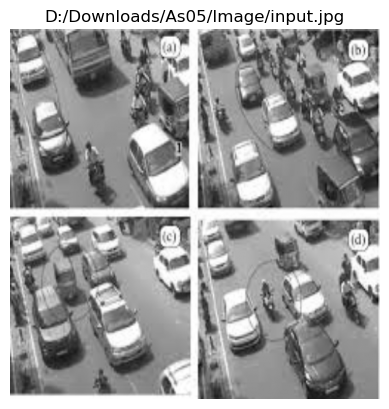


Processing: D:/Downloads/As05/Image/image2.jpg
✅ Image loaded


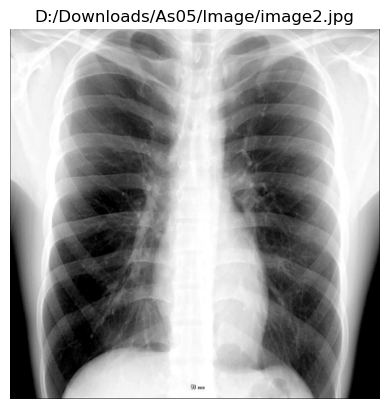


Processing: D:/Downloads/As05/Image/image3.jpg
✅ Image loaded


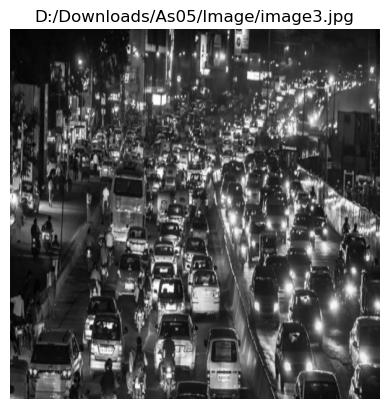


--- Adding Noise ---

--- PERFORMANCE ---
MSE: 61.17
PSNR: 30.27
SSIM: 0.8


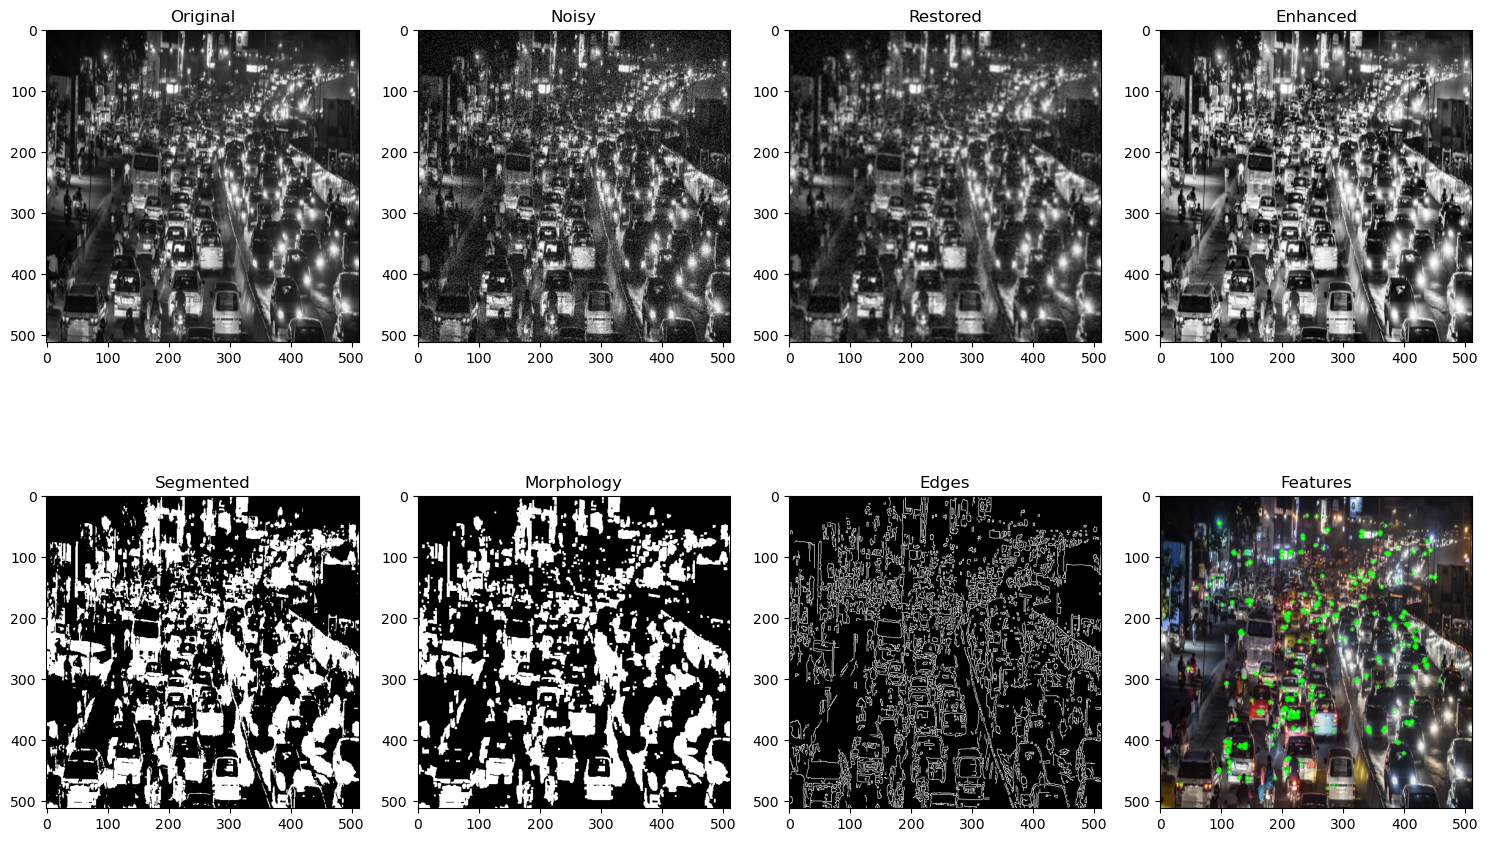


✅ ALL OUTPUTS SAVED
===== SYSTEM COMPLETED =====


In [ ]:
# ===============================
# Name: Sahil Bhardwaj
# Course: Image Processing & Computer Vision
# Assignment: Intelligent Image Enhancement & Analysis System
# ===============================

# !pip install opencv-python numpy matplotlib scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage.metrics import structural_similarity as ssim

print("===== INTELLIGENT IMAGE PROCESSING SYSTEM =====")


# ===============================
# LOAD IMAGE (FIX THIS PATH)
# ===============================
image_paths = [
    "D:/Downloads/As05/Image/input.jpg",
    "D:/Downloads/As05/Image/image2.jpg",
    "D:/Downloads/As05/Image/image3.jpg"
]

for image_path in image_paths:
    print("\nProcessing:", image_path)

    image = cv2.imread(image_path)

    if image is None:
        print("❌ ERROR: Image not loaded:", image_path)
        continue

    print("✅ Image loaded")

    # Resize + grayscale
    image = cv2.resize(image, (512, 512))
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Show image
    import matplotlib.pyplot as plt
    plt.imshow(gray, cmap='gray')
    plt.title(image_path)
    plt.axis('off')
    plt.show()

    # 👉 paste your FULL pipeline code here (noise, segmentation, etc.)
# ===============================
# TASK 3: ADD NOISE
# ===============================
print("\n--- Adding Noise ---")

# Gaussian Noise
gaussian_noise = gray + np.random.normal(0, 25, gray.shape)
gaussian_noise = np.clip(gaussian_noise, 0, 255).astype(np.uint8)

# Salt & Pepper
sp_noise = gray.copy()
prob = 0.02
rnd = np.random.rand(*gray.shape)
sp_noise[rnd < prob] = 0
sp_noise[rnd > 1 - prob] = 255


# ===============================
# RESTORATION
# ===============================
mean = cv2.blur(gaussian_noise, (5,5))
median = cv2.medianBlur(sp_noise, 5)
gaussian = cv2.GaussianBlur(gaussian_noise, (5,5), 0)

# Contrast Enhancement
clahe = cv2.createCLAHE(clipLimit=2.0)
enhanced = clahe.apply(gray)


# ===============================
# SEGMENTATION
# ===============================
_, global_thresh = cv2.threshold(enhanced, 127, 255, cv2.THRESH_BINARY)
_, otsu = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


# ===============================
# MORPHOLOGY
# ===============================
kernel = np.ones((3,3), np.uint8)
erosion = cv2.erode(otsu, kernel, 1)
dilation = cv2.dilate(erosion, kernel, 1)


# ===============================
# EDGE DETECTION
# ===============================
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
sobel = cv2.magnitude(sobelx, sobely)

canny = cv2.Canny(gray, 100, 200)


# ===============================
# CONTOURS
# ===============================
contours, _ = cv2.findContours(canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = image.copy()

for cnt in contours:
    if cv2.contourArea(cnt) > 500:
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(output, (x,y), (x+w,y+h), (0,255,0), 2)


# ===============================
# FEATURE EXTRACTION (ORB)
# ===============================
orb = cv2.ORB_create()
kp, des = orb.detectAndCompute(gray, None)
orb_img = cv2.drawKeypoints(image, kp, None, color=(0,255,0))


# ===============================
# METRICS (MSE, PSNR, SSIM)
# ===============================
def mse(img1, img2):
    return np.mean((img1 - img2) ** 2)

def psnr(img1, img2):
    m = mse(img1, img2)
    if m == 0:
        return 100
    return 20 * np.log10(255.0 / np.sqrt(m))

mse_val = mse(gray, gaussian)
psnr_val = psnr(gray, gaussian)
ssim_val = ssim(gray, gaussian)

print("\n--- PERFORMANCE ---")
print("MSE:", round(mse_val,2))
print("PSNR:", round(psnr_val,2))
print("SSIM:", round(ssim_val,2))


# ===============================
# FINAL VISUALIZATION
# ===============================
plt.figure(figsize=(15,10))

plt.subplot(2,4,1); plt.imshow(gray, cmap='gray'); plt.title("Original")
plt.subplot(2,4,2); plt.imshow(gaussian_noise, cmap='gray'); plt.title("Noisy")
plt.subplot(2,4,3); plt.imshow(gaussian, cmap='gray'); plt.title("Restored")
plt.subplot(2,4,4); plt.imshow(enhanced, cmap='gray'); plt.title("Enhanced")

plt.subplot(2,4,5); plt.imshow(otsu, cmap='gray'); plt.title("Segmented")
plt.subplot(2,4,6); plt.imshow(dilation, cmap='gray'); plt.title("Morphology")
plt.subplot(2,4,7); plt.imshow(canny, cmap='gray'); plt.title("Edges")
plt.subplot(2,4,8); plt.imshow(cv2.cvtColor(orb_img, cv2.COLOR_BGR2RGB)); plt.title("Features")

plt.tight_layout()
plt.show()


# ===============================
# SAVE OUTPUTS
# ===============================
os.makedirs("outputs", exist_ok=True)

cv2.imwrite("outputs/original.png", gray)
cv2.imwrite("outputs/noisy.png", gaussian_noise)
cv2.imwrite("outputs/restored.png", gaussian)
cv2.imwrite("outputs/enhanced.png", enhanced)
cv2.imwrite("outputs/segmented.png", otsu)
cv2.imwrite("outputs/features.png", orb_img)

print("\n✅ ALL OUTPUTS SAVED")
print("===== SYSTEM COMPLETED =====")